# Winograd convolution

So, the english is not very good, I will improve that

In [41]:
import itertools

import sympy as sy
import numpy as np

In [42]:
import fitz

from utils import plot_pdf, symmetrical_polynomial_factorization

In [43]:
doc = fitz.open('/home/tarsio/zotero-lib/AUTH/Blahut/Blahut_2010_Fast algorithms for signal processing.pdf')

The base for this tutorial is the book "Fast Algorithms or Signal Processing" of Blahut.
Is an excellent book but full of examples but, of course, do not explain everything in details.
For that parts I will quote another books and videos from Youtube.

In this tutorial I will quote the theoretical first and the example after that for best understanding.

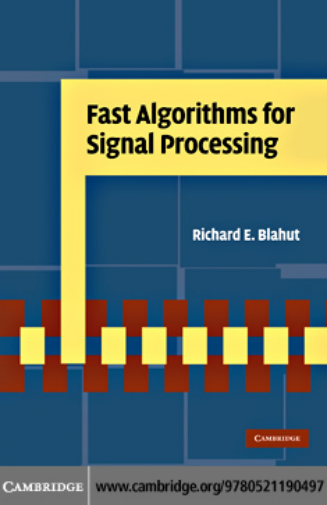

In [44]:
plot_pdf(doc[0], dpi=100)

## Polynomials

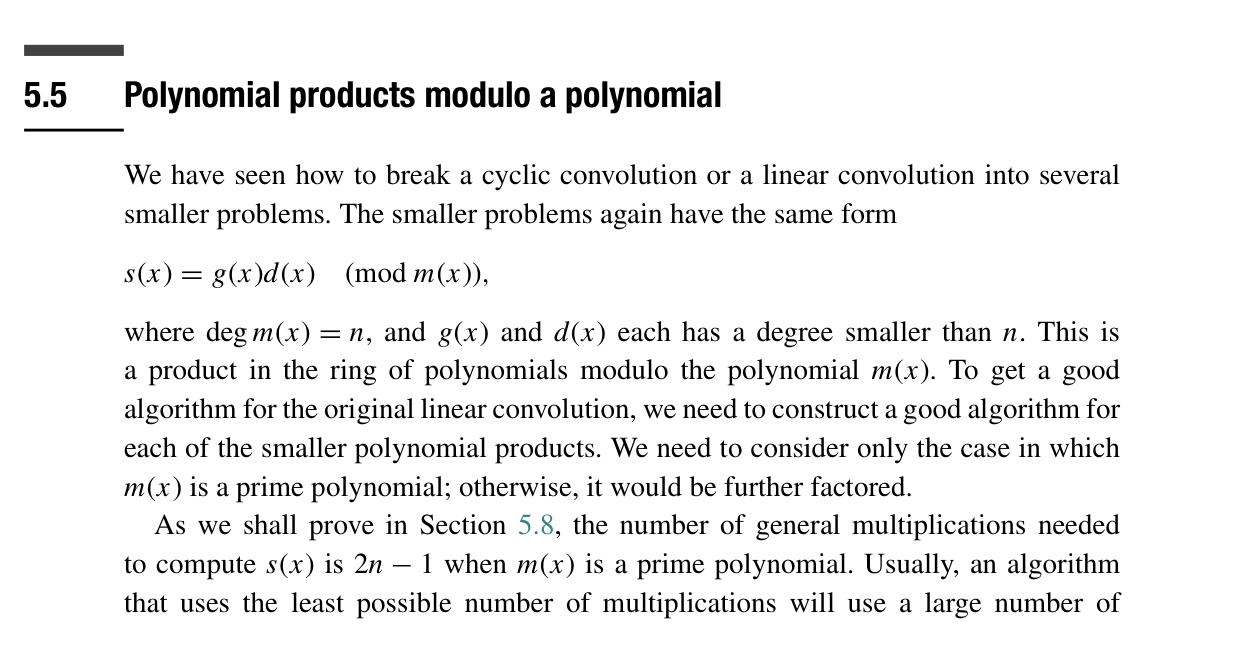

In [45]:
plot_pdf(doc[183], [.6, .95])

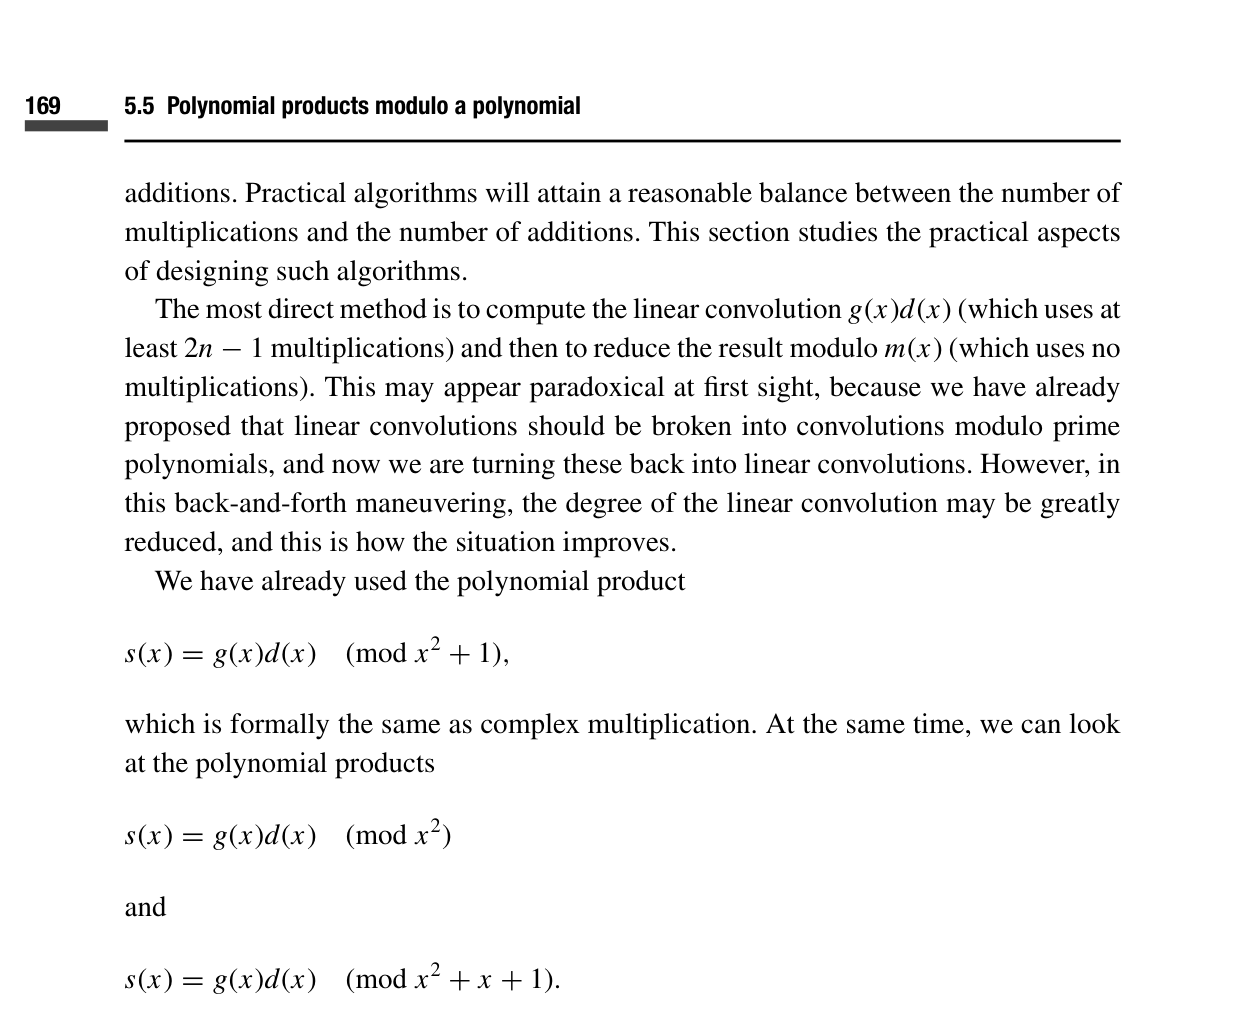

In [46]:
plot_pdf(doc[184], [0, .54])

Size of vectors

In [47]:
d_num = 2
g_num = 2

Example of vectors for the convolution

In [48]:
d_values = list(range(1, d_num+1))
g_values = list(range(1, g_num+1))
print(d_values, g_values)

[1, 2] [1, 2]


Polynomial degree

In [49]:
d_degree = d_num - 1
g_degree = g_num - 1
print(d_degree, g_degree)

1 1


In [50]:
x = sy.symbols("x")
x

x

In [51]:
di = sy.Matrix(sy.symbols(" ".join(f"d_{i}"for i in range(d_num))))
di

Matrix([
[d_0],
[d_1]])

In [52]:
gi = sy.Matrix(sy.symbols(" ".join(f"g_{i}"for i in range(g_num))))
gi

Matrix([
[g_0],
[g_1]])

In [53]:
dx = sum([i*x**e for e, i in enumerate(di)])
dx

d_0 + d_1*x

In [54]:
gx = sum([i*x**e for e, i in enumerate(gi)])
gx

g_0 + g_1*x

In [55]:
sx = gx*dx
sx

(d_0 + d_1*x)*(g_0 + g_1*x)

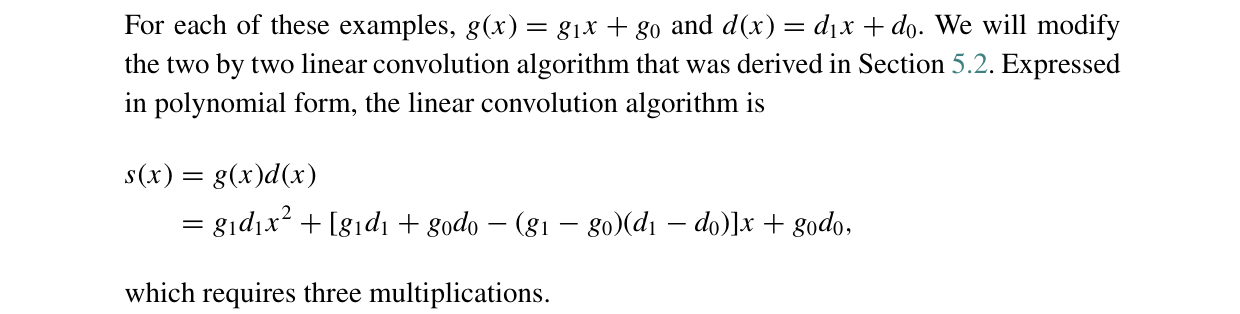

In [56]:
plot_pdf(doc[184], [.54, .705])


To avoid making the notebook unnecessary to long, we will show only the first example

In [57]:
sx.expand().collect(x)

d_0*g_0 + d_1*g_1*x**2 + x*(d_0*g_1 + d_1*g_0)

In [58]:
sum(gi)*sum(di)

(d_0 + d_1)*(g_0 + g_1)

In [59]:
conv = np.convolve(np.array(di).reshape(-1), np.array(gi).reshape(-1))
sy.Matrix(conv)

Matrix([
[          d_0*g_0],
[d_0*g_1 + d_1*g_0],
[          d_1*g_1]])

In [60]:
# conv = np.convolve(dx.args, gx.args)
# sy.Matrix(conv)

In [63]:
di

Matrix([
[d_0],
[d_1]])

In [64]:
s0 = [symmetrical_polynomial_factorization(i, di, gi) for i in conv[1:-1]]
si = sy.Matrix([conv[0]] + s0 + [conv[-1]])
si

Matrix([
[                                     d_0*g_0],
[-d_0*g_0 - d_1*g_1 + (d_0 + d_1)*(g_0 + g_1)],
[                                     d_1*g_1]])

In [65]:
sx = sum([i*x**e for e, i in enumerate(si)])
sx.collect(x)

d_0*g_0 + d_1*g_1*x**2 + x*(-d_0*g_0 - d_1*g_1 + (d_0 + d_1)*(g_0 + g_1))

In [66]:
sx0 = sx.subs({x**2: -1})
sx0

d_0*g_0 - d_1*g_1 + x*(-d_0*g_0 - d_1*g_1 + (d_0 + d_1)*(g_0 + g_1))

In [67]:
sx1 = sx.subs({x**2: 0})
sx1

d_0*g_0 + x*(-d_0*g_0 - d_1*g_1 + (d_0 + d_1)*(g_0 + g_1))

In [68]:
sx2 = sx.subs({x**2: x-1})
sx2

d_0*g_0 + d_1*g_1*(x - 1) + x*(-d_0*g_0 - d_1*g_1 + (d_0 + d_1)*(g_0 + g_1))

In [69]:
expr = (di[0]+di[1])*(gi[0]+gi[1])

In [70]:
sx2b = (sx2.subs({expr: 0}).expand() + x*expr).collect(x)
sx2b

d_0*g_0 - d_1*g_1 + x*(-d_0*g_0 + (d_0 + d_1)*(g_0 + g_1))

In [76]:
sy.degree(sx, x)

2

In [106]:
sx0_args = sorted(
    (dict.fromkeys((-1)*a if str(a).startswith("-") else a  for d in range(sy.degree(sx, x)+1) for a in sx0.coeff(x, d).args)),
    key=lambda i: len(str(i))
)
sy.Matrix(sx0_args)

Matrix([
[                d_0*g_0],
[                d_1*g_1],
[(d_0 + d_1)*(g_0 + g_1)]])

In [101]:
sx0_list_ = [sum(sx0.coeff(x, d).args)  for d in range(sy.degree(sx, x)+1)]
sx0_list = [s for s in sx0_list_ if s != 0]
sy.Matrix(sx0_list)

Matrix([
[                           d_0*g_0 - d_1*g_1],
[-d_0*g_0 - d_1*g_1 + (d_0 + d_1)*(g_0 + g_1)]])

In [123]:
a_mtx = sy.Matrix([[1 if s.coeff(a, 1) != 0 else 0 for a in di] for s in sy.Matrix(sx0_args).expand()])
a_mtx.tolist()

[[1, 0], [0, 1], [1, 1]]

In [124]:
b_mtx = sy.Matrix([[1 if s.coeff(a, 1) != 0 else 0 for a in gi] for s in sy.Matrix(sx0_args).expand()])
b_mtx.tolist()


[[1, 0], [0, 1], [1, 1]]

In [121]:
bg_mtx = sy.diag(*(b_mtx * gi))
bg_mtx

[[g_0, 0, 0], [0, g_1, 0], [0, 0, g_0 + g_1]]

In [122]:
c_mtx = sy.Matrix([[s.coeff(a, 1) for a in sx0_args] for s in sx0_list])
c_mtx

[[1, -1, 0], [-1, -1, 1]]

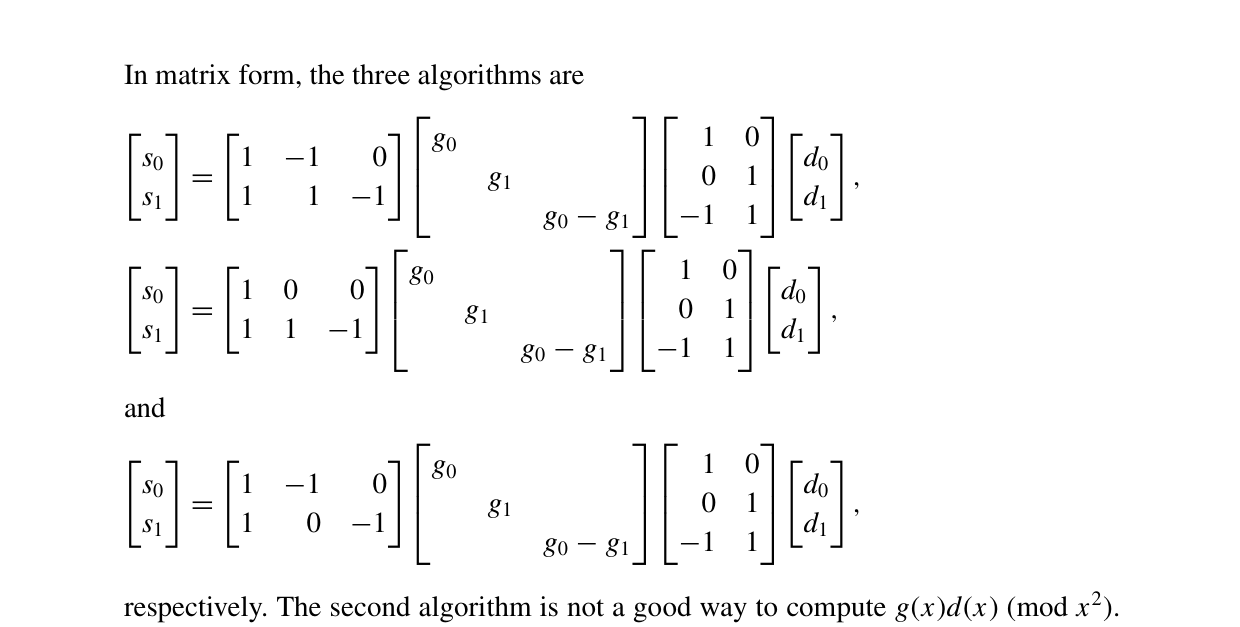

In [139]:
plot_pdf(doc[185], [.35, .68])


In [117]:
s0 = sy.MatMul(c_mtx, bg_mtx, a_mtx, di)
s0

Matrix([
[ 1, -1, 0],
[-1, -1, 1]])*Matrix([
[g_0,   0,         0],
[  0, g_1,         0],
[  0,   0, g_0 + g_1]])*Matrix([
[1, 0],
[0, 1],
[1, 1]])*Matrix([
[d_0],
[d_1]])

In [118]:
sy.MatMul(c_mtx, bg_mtx, a_mtx, di, evaluate=True)

Matrix([
[d_0*g_0 - d_1*g_1],
[d_0*g_1 + d_1*g_0]])

Comparing with book result

In [131]:
sy.MatMul(
    sy.Matrix([[1, -1, 0], [-1, -1, 1]]),
    sy.Matrix([[gi[0], 0, 0], [0, gi[1], 0], [0, 0, gi[0] + gi[1]]]),
    sy.Matrix([[1, 0], [0, 1], [1, 1]]),
    di,
    evaluate=True)

Matrix([
[d_0*g_0 - d_1*g_1],
[d_0*g_1 + d_1*g_0]])

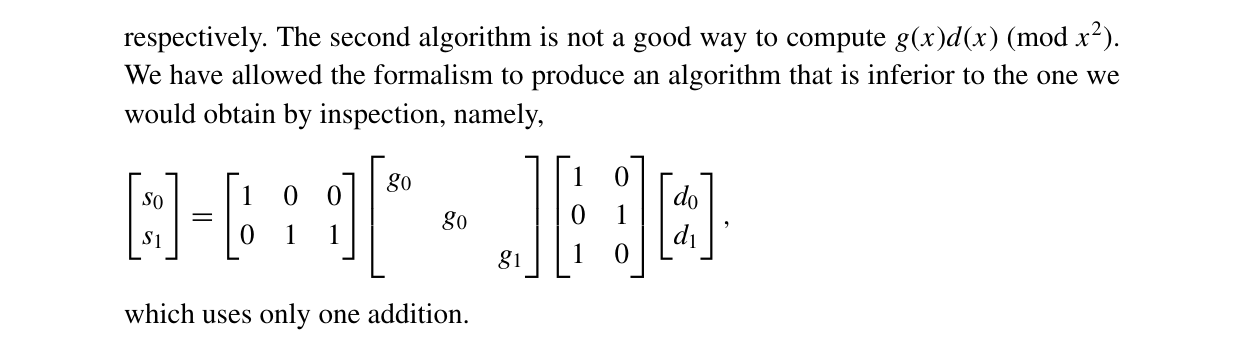

In [145]:
plot_pdf(doc[185], [.65, .83])
